# Streaming Accumulation - WIP!

This notebook demonstrates the streaming accumulation workflow within the HEALPix framework, including sidecar creation, data aggregation, grid densification, and map visualization. As a Work In Progress (WIP), it is exploratory and subject to rapid API changes and refinements.

## Setup

Import the healpyxel package and core utilities:

In [1]:
import healpyxel
from healpyxel.sidecar import process_partition
from healpyxel.aggregate import aggregate_by_sidecar, densify_healpix_aggregates
import pandas as pd
import numpy as np
import geopandas as gpd
from pathlib import Path
from shapely import wkb

print(f"healpyxel version: {healpyxel.__version__}")

healpyxel version: 0.1.0


## Test Data Discovery

Find available batch data files:

In [2]:
# Look for test data
test_data_dir = Path('../test_data')
batches_dir = test_data_dir / 'batches'

if batches_dir.exists():
    batch_files = sorted(batches_dir.glob('batch_*.parquet'))
    print(f"Found {len(batch_files)} batch files!")
    print(f"\nFirst few batches:")
    for f in batch_files:
        size_mb = f.stat().st_size / 1024 / 1024
        print(f"  {f.name}: {size_mb:.2f} MB")
else:
    print("Batch data not found. Run create_test_data.sh to generate test data.")
    batch_files = []

Found 10 batch files!

First few batches:
  batch_001.parquet: 1.12 MB
  batch_002.parquet: 1.51 MB
  batch_003.parquet: 1.37 MB
  batch_004.parquet: 1.46 MB
  batch_005.parquet: 1.66 MB
  batch_006.parquet: 1.42 MB
  batch_007.parquet: 1.53 MB
  batch_008.parquet: 1.64 MB
  batch_009.parquet: 1.61 MB
  batch_010.parquet: 1.80 MB


In [3]:
from healpyxel.geospatial import is_geometry_valid

batch_files_loaded = [
    gdf[gdf['geometry'].apply(is_geometry_valid)]
    for gdf in (gpd.read_parquet(f) for f in batch_files)
]

import rich 
print("Number of geometries in each batch:")
rich.print({k.stem : len(gdf) for k, gdf in zip(batch_files, batch_files_loaded)})

Number of geometries in each batch:


{
    'batch_001': 3027,
    'batch_002': 4124,
    'batch_003': 3734,
    'batch_004': 3989,
    'batch_005': 4501,
    'batch_006': 3885,
    'batch_007': 4174,
    'batch_008': 4479,
    'batch_009': 4416,
    'batch_010': 4931
}

In [4]:
import matplotlib.pyplot as plt

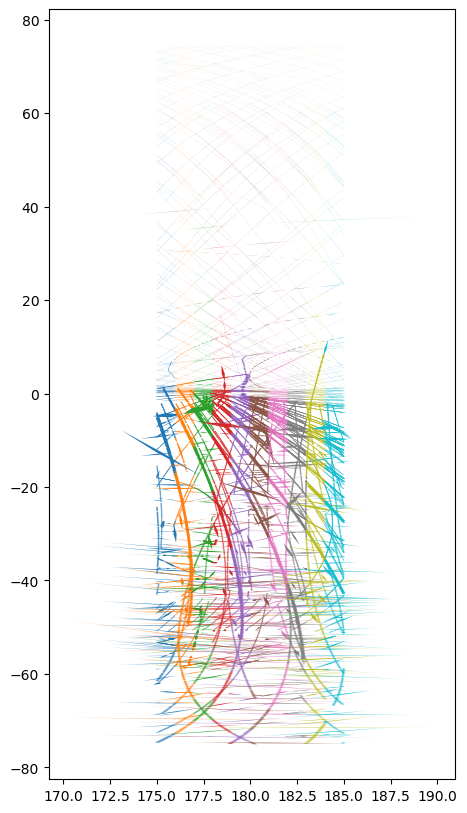

In [6]:
fig, ax = plt.subplots(figsize=(20, 10))
colors = plt.cm.tab10.colors  # Use a colormap for distinct colors
for i, gdf in enumerate(batch_files_loaded):
    gdf.plot(ax=ax, color=colors[i % len(colors)], linewidth=3)
    # axs[i].set_xlim(150, 180)
ax.set_aspect(0.25)  # Ensure the aspect ratio of the figure is respected

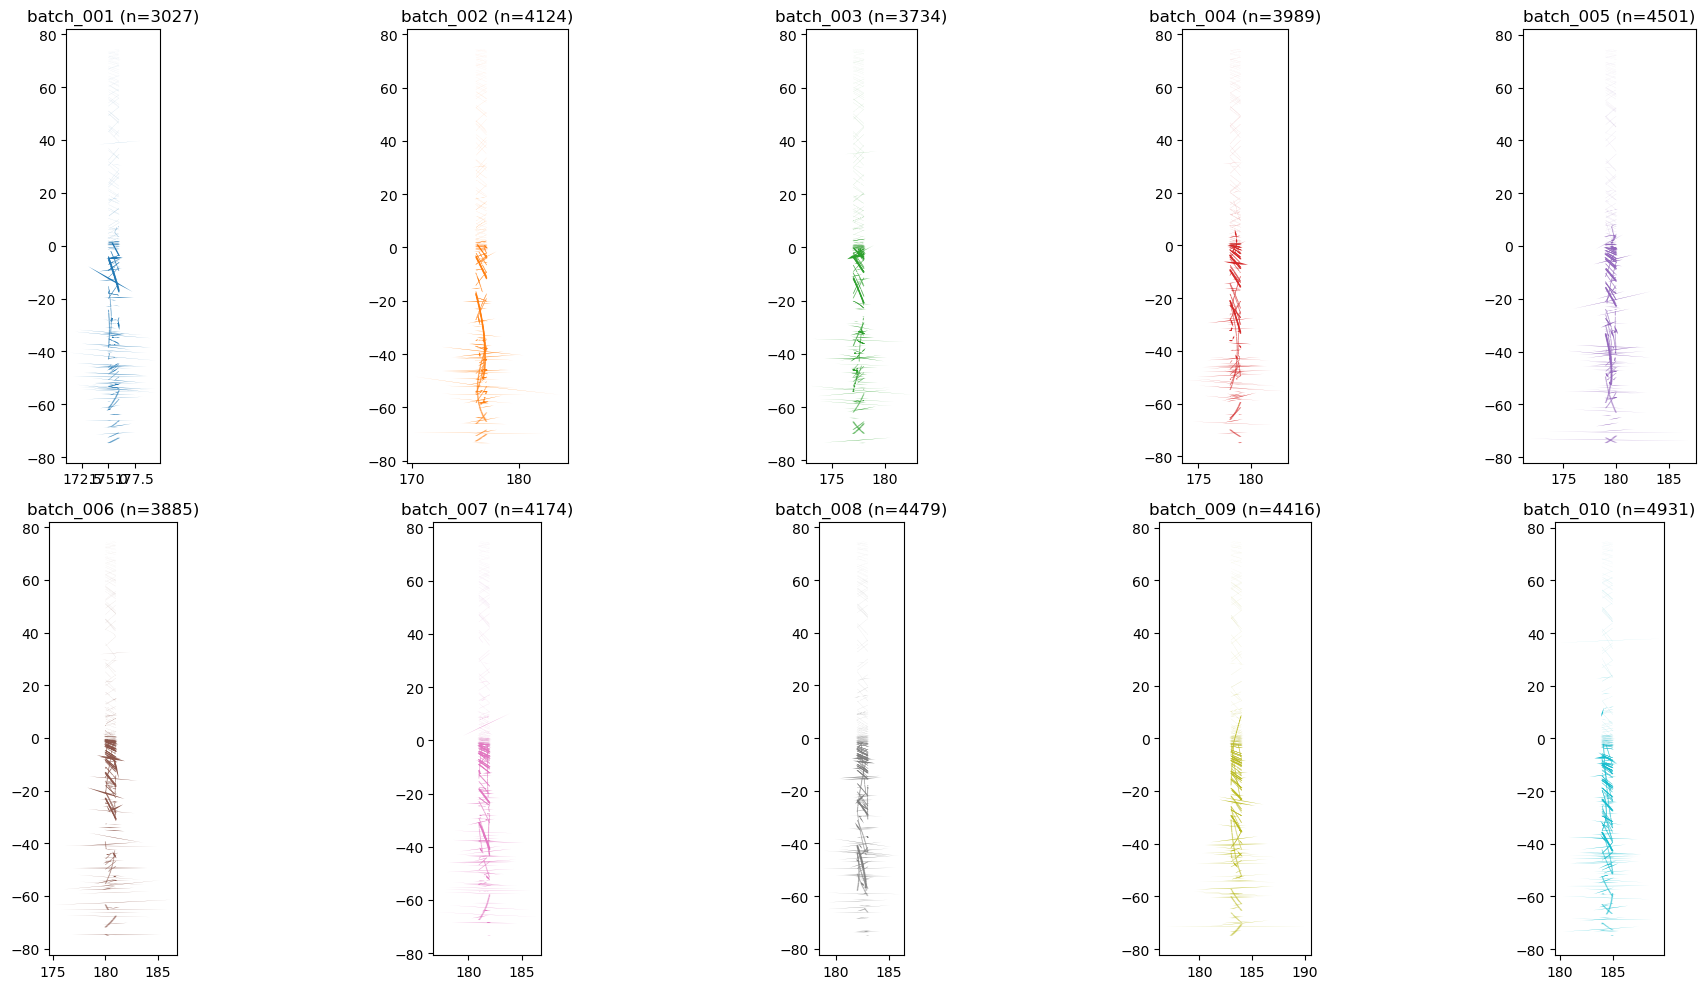

In [ ]:
fig, axs = plt.subplots(nrows=2,ncols=5, figsize=(20, 10))
colors = plt.cm.tab10.colors  # Use a colormap for distinct colors
axs = axs.flatten()  # Flatten the 2D array of axes for easy iteration
for i, gdf in enumerate(batch_files_loaded):
    gdf.plot(ax=axs[i], color=colors[i % len(colors)], linewidth=3)
    # axs[i].set_xlim(150, 180)
    axs[i].set_aspect(0.25)  # Ensure the aspect ratio of the figure is respected
    axs[i].set_title(f"{batch_files[i].stem} (n={len(gdf)})")

plt.tight_layout()

## Step 1: Create Sidecar for Each Batch

Process each batch file to create HEALPix assignments:

In [10]:
#| eval: false
# Configuration
nside = 32  # HEALPix resolution
mode = 'fuzzy'  # Assignment mode
lon_convention = '0_360'  # Longitude range of input data

# Process first few batches as demonstration (adjust as needed)
n_batches_to_process = len(batch_files_loaded)

sidecars = []
for i, gdf in enumerate(batch_files_loaded[:n_batches_to_process]):
    print(f"\n[{i+1}/{n_batches_to_process}] Processing batch {i+1}...")

    # Ensure the GeoDataFrame has valid geometries
    if gdf.empty or 'geometry' not in gdf.columns:
        print(f"  ⚠️  No valid geometry column found in batch {i+1}, skipping...")
        continue

    # Create sidecar
    sidecar = process_partition(
        gdf=gdf,
        nside=nside,
        mode=mode,
        base_index=0,
        lon_convention=lon_convention  # Use lon_convention instead of lat_min/lat_max
    )
    
    # Store with batch info
    sidecar['batch'] = i
    sidecars.append(sidecar)
    
    print(f"  ✓ Created {len(sidecar)} assignments from {len(gdf)} geometries")
    print(f"    Unique cells: {sidecar['healpix_id'].nunique()}")

# Combine all sidecars if any were created
if sidecars:
    combined_sidecar = pd.concat(sidecars, ignore_index=True)
    print(f"\n{'='*60}")
    print(f"Combined sidecar: {len(combined_sidecar)} total assignments")
    print(f"Unique cells touched: {combined_sidecar['healpix_id'].nunique()}")
    print(f"Unique sources: {combined_sidecar['source_id'].nunique()}")
else:
    print("\nNo sidecars created. Check that batch files exist and have valid geometry columns.")


[1/10] Processing batch 1...
  ✓ Created 3539 assignments from 3027 geometries
    Unique cells: 157

[2/10] Processing batch 2...
  ✓ Created 4782 assignments from 4124 geometries
    Unique cells: 140

[3/10] Processing batch 3...
  ✓ Created 4304 assignments from 3734 geometries
    Unique cells: 151

[4/10] Processing batch 4...
  ✓ Created 4565 assignments from 3989 geometries
    Unique cells: 156

[5/10] Processing batch 5...
  ✓ Created 5308 assignments from 4501 geometries
    Unique cells: 160

[6/10] Processing batch 6...
  ✓ Created 4552 assignments from 3885 geometries
    Unique cells: 160

[7/10] Processing batch 7...
  ✓ Created 4874 assignments from 4174 geometries
    Unique cells: 160

[8/10] Processing batch 8...
  ✓ Created 5205 assignments from 4479 geometries
    Unique cells: 147

[9/10] Processing batch 9...
  ✓ Created 5134 assignments from 4416 geometries
    Unique cells: 143

[10/10] Processing batch 10...
  ✓ Created 5632 assignments from 4931 geometries


## Step 2: Aggregate Data by HEALPix Cells

Now aggregate the original data values by HEALPix cell using the sidecar:

In [12]:
#| eval: false
# Reload and combine data from processed batches (drop geometry for aggregation)
combined_data_list = []

for i, gdf in enumerate(batch_files_loaded[:n_batches_to_process]):
    print(f"\n[{i+1}/{n_batches_to_process}] Processing batch {i+1}...")

    # Drop geometry column if present (not needed for aggregation)
    if 'geometry' in gdf.columns:
        gdf = gdf.drop(columns=['geometry'])
    
    # Add source_id matching the sidecar creation
    gdf['source_id'] = gdf.index.astype(np.int64)
    gdf['batch'] = i
    combined_data_list.append(gdf)

if combined_data_list:
    combined_data = pd.concat(combined_data_list, ignore_index=True)
    print(f"Combined data: {len(combined_data)} rows")
    print(f"Columns: {list(combined_data.columns)}")
    print(f"\nFirst few rows:")
    display(combined_data.head())
else:
    print("No data combined. Check that batch_files_loaded contains valid data.")


[1/10] Processing batch 1...

[2/10] Processing batch 2...

[3/10] Processing batch 3...

[4/10] Processing batch 4...

[5/10] Processing batch 5...

[6/10] Processing batch 6...

[7/10] Processing batch 7...

[8/10] Processing batch 8...

[9/10] Processing batch 9...

[10/10] Processing batch 10...
Combined data: 41260 rows
Columns: ['ref_id', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q1', 'q2', 'q3', 'q4', 'obs_id', 'vis_slope', 'nir_slope', 'visnir_slope', 'norm_vis_slope', 'norm_nir_slope', 'norm_visnir_slope', 'curvature', 'norm_curvature', 'uv_downturn', 'color_index_310_390', 'color_index_415_750', 'color_index_750_415', 'color_index_750_950', 'r310', 'r390', 'r750', 'r950', 'r1050', 'r1400', 'r415', 'r433_2', 'r479_9', 'r556_9', 'r628_8', 'r748_7', 'r828_4', 'r898_8', 'r996_2', 'spot_number', 'lat_center', 'lon_center', 'surface', 'width', 'length', 'ang_incidence', 'ang_emission', 'ang_phase', 'azimuth', 'source_id', 'batch']

First few 

,ref_id,a,b,c,d,e,f,g,h,i,...,lon_center,surface,width,length,ang_incidence,ang_emission,ang_phase,azimuth,source_id,batch
0,0801419125400568,0,0,0,0,0,1,0,0,0,...,175.06512,54194396.0,5599.9224,12322.036,9.834717,73.333954,83.013830,154.51570,0,0
1,0801419125400569,0,0,0,0,0,1,0,0,0,...,175.14010,54753300.0,5660.6910,12315.469,9.769003,73.381120,82.985110,154.42958,1,0
2,0801419125400570,0,0,0,0,0,1,0,0,0,...,175.21364,54823684.0,5736.7520,12167.806,9.704690,73.427300,82.956314,154.33447,2,0
3,0801419125400571,0,0,0,0,0,1,0,0,0,...,175.28458,54962964.0,5861.2773,11939.551,9.641157,73.473150,82.927510,154.23120,3,0
4,0801419125400572,0,0,0,0,0,1,0,0,0,...,175.35536,55392168.0,5779.1610,12203.761,9.577167,73.520050,82.898830,154.12103,4,0


In [13]:
#| eval: false
# Choose a value column to aggregate (adjust based on your data)
# Common columns in MESSENGER MASCS data: r1050, r750, etc.
value_columns = ['r1050'] if 'r1050' in combined_data.columns else []

if not value_columns:
    # Try to find numeric columns
    numeric_cols = combined_data.select_dtypes(include=[np.number]).columns.tolist()
    # Exclude id and coordinate columns
    exclude = ['source_id', 'batch', 'lat_center', 'lon_center', 'lat', 'lon', 'latitude', 'longitude']
    value_columns = [c for c in numeric_cols if c not in exclude][:1]  # Take first suitable column

print(f"Aggregating column(s): {value_columns}")

if value_columns and sidecars:
    # Perform aggregation
    aggregated = aggregate_by_sidecar(
        original=combined_data,
        sidecar=combined_sidecar,
        value_columns=value_columns,
        aggs=['mean', 'median', 'std', 'mad', 'robust_std'],
        source_id_col='source_id',
        healpix_col='healpix_id',
        min_count=1,
       sentinel_threshold=1e30
    )
    
    print(f"\nAggregated {len(aggregated)} HEALPix cells")
    print(f"Columns: {list(aggregated.columns)}")
    display(aggregated.head(10))
else:
    print("Cannot aggregate: no suitable value columns or no sidecars created")

2026-02-13 13:31:15,506 WARNING Found 36329 duplicate source_id values - keeping first occurrence
2026-02-13 13:31:15,516 INFO Sidecar source_id overlap: 4931/4931 (100.0%)
2026-02-13 13:31:15,517 INFO Merging sidecar with original data
2026-02-13 13:31:15,523 INFO Grouping by healpix_id and computing aggregations
2026-02-13 13:31:15,531 INFO Processing 458 HEALPix cells


Aggregating column(s): ['r1050']


Aggregating HEALPix cells:   0%|          | 0/458 [00:00<?, ?cell/s]

2026-02-13 13:31:15,728 INFO Aggregation complete: 458 cells with data



Aggregated 458 HEALPix cells
Columns: ['r1050_mean', 'r1050_median', 'r1050_std', 'r1050_mad', 'r1050_robust_std', 'n_sources']


,r1050_mean,r1050_median,r1050_std,r1050_mad,r1050_robust_std,n_sources
healpix_id,,,,,,
1360,0.064800,0.064958,0.002333,0.002149,0.003187,4
1361,0.056111,0.053312,0.009071,0.006254,0.009272,67
1364,0.052999,0.052222,0.009556,0.005086,0.007540,121
1365,0.055351,0.052325,0.011867,0.002711,0.004019,84
1366,0.061883,0.062385,0.008684,0.006037,0.008951,86
1367,0.051103,0.050074,0.006332,0.002375,0.003521,116
1372,0.058407,0.058615,0.007742,0.005122,0.007594,116
1373,0.052792,0.052738,0.009365,0.004715,0.006991,143
1374,0.056128,0.054841,0.006303,0.004398,0.006521,111


## Step 3: Densify for Complete HEALPix Grid

Fill in empty cells to create a complete HEALPix map:

In [ ]:
#| eval: false
if value_columns and sidecars:
    # Densify the sparse aggregated data
    aggregated_dense = densify_healpix_aggregates(
        agg_sparse_df=aggregated,
        nside=nside,
        healpix_col='healpix_id'
    )
    
    total_cells = 12 * nside ** 2
    filled_cells = aggregated[f'{value_columns[0]}_mean'].notna().sum()
    empty_cells = total_cells - filled_cells
    
    print(f"HEALPix Grid (nside={nside}):")
    print(f"  Total cells: {total_cells}")
    print(f"  Cells with data: {filled_cells}")
    print(f"  Empty cells: {empty_cells}")
    print(f"  Coverage: {100 * filled_cells / total_cells:.2f}%")
    
    display(aggregated_dense.head(10))

2026-02-13 13:31:35,234 INFO Densified from 458 to 12288 cells (nside=32)


HEALPix Grid (nside=32):
  Total cells: 12288
  Cells with data: 458
  Empty cells: 11830
  Coverage: 3.73%


,r1050_mean,r1050_median,r1050_std,r1050_mad,r1050_robust_std,n_sources
healpix_id,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN


## Step 4: Visualize HEALPix Map

Create a visualization of the aggregated data:

2025-12-11 15:11:07,965 INFO 0.0 180.0 -180.0 180.0
2025-12-11 15:11:07,966 INFO The interval between parallels is 30 deg -0.00'.
2025-12-11 15:11:07,967 INFO The interval between meridians is 30 deg -0.00'.
2025-12-11 15:11:07,966 INFO The interval between parallels is 30 deg -0.00'.
2025-12-11 15:11:07,967 INFO The interval between meridians is 30 deg -0.00'.


<Figure size 1200x800 with 0 Axes>

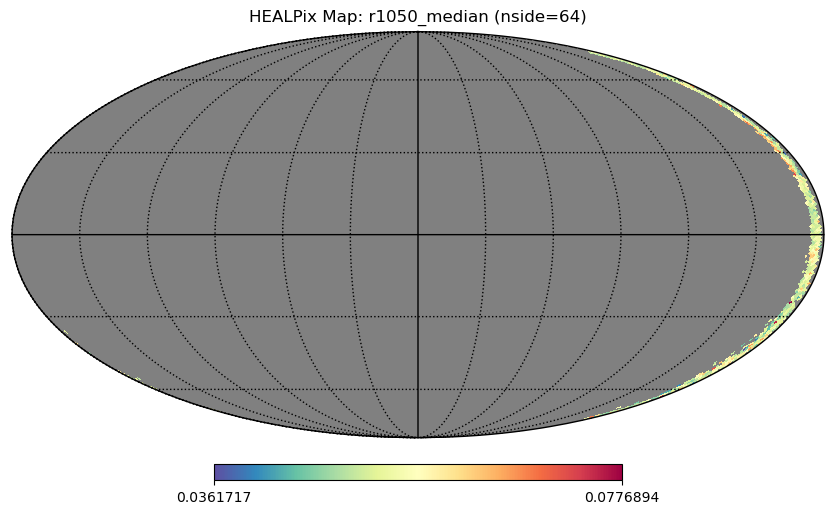


Map Statistics:
  Min: 0.0362
  Max: 0.0777
  Mean: 0.0535
  Median: 0.0527


In [ ]:
#| eval: false
if value_columns and sidecars:
    import healpy as hp
    import matplotlib.pyplot as plt
    
    # Choose which statistic to visualize
    stat_column = f'{value_columns[0]}_median'
    
    # Extract map values (NaN for empty cells)
    healpix_map = aggregated_dense[stat_column].values.astype(float)
    
    # Create visualization
    plt.figure(figsize=(12, 8))
    hp.mollview(
        healpix_map,
        nest=True,
        title=f'HEALPix Map: {stat_column} (nside={nside})',
        cmap='Spectral_r',
        flip='geo',
        xsize=2000
    )
    hp.graticule()
    plt.show()
    
    # Statistics of the mapped data
    valid_data = healpix_map[~np.isnan(healpix_map)]
    print(f"\nMap Statistics:")
    print(f"  Min: {valid_data.min():.4f}")
    print(f"  Max: {valid_data.max():.4f}")
    print(f"  Mean: {valid_data.mean():.4f}")
    print(f"  Median: {np.median(valid_data):.4f}")

## Summary

This notebook demonstrated the complete healpyxel workflow:

1. **Sidecar Creation**: Assigned HEALPix cells to geometries using `process_partition()`
2. **Aggregation**: Computed statistics per cell using `aggregate_by_sidecar()`
3. **Densification**: Created complete grid using `densify_healpix_aggregates()`
4. **Visualization**: Displayed the final HEALPix map

### For Large Datasets

For processing many batch files efficiently, use the CLI tools:

```bash
# Process all batches with sidecar creation
for batch in test_data/batches/batch_*.parquet; do
    healpix_sidecar --input "$batch" \
                    --nside 32 64 \
                    --mode fuzzy \
                    --lon-convention 0_360 \
                    --ncores 4
done

# Aggregate all data
healpix_aggregate --input test_data/batches/ \
                  --pattern "*.parquet" \
                  --nside 32 \
                  --output aggregated_nside32.parquet

# Finalize maps
healpix_finalize --input aggregated_nside32.parquet \
                 --nside 32 \
                 --output final_maps/
```

### Next Steps

- Experiment with different `nside` values for different resolutions
- Try both 'strict' and 'fuzzy' assignment modes
- Aggregate multiple value columns simultaneously
- Use `finalize_maps()` to create production-ready map products